# Кластеризация физической активности — PAMAP2

Соревнование на Kaggle: https://www.kaggle.com/competitions/clustering-physical-activity

Дано: 534 601 наблюдение с трёх IMU (рука / грудь / щиколотка) + пульсометра, 8 испытуемых, без меток.  
Нужно: разбить точки на 12 классов активности и сматчить кластеры к activity_id из протокола PAMAP2.

Метрика — Categorization Accuracy, по сути доля совпадений с реальными метками.

План:
1. посмотреть данные глазами, понять что есть
2. почистить пропуски, удалить мусорные колонки
3. сделать фичи (магнитуды + rolling) — без этого кластеры будут как каша
4. PCA для скорости и устранения шумных направлений
5. KMeans (+ GMM как альтернатива)
6. temporal smoothing — критично, активности идут длинными «полками»
7. сматчить кластеры к activityID по интенсивности (proxy = chest acc magnitude)


## 1. Импорты и сиды


In [1]:
import os, json, time, random, warnings, re, urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
print('numpy', np.__version__, '| pandas', pd.__version__)


numpy 2.4.5 | pandas 3.0.3


## 2. Данные

Чтобы не таскать архив руками — пробуем подтянуть через Kaggle API (новый формат токена `KGAT_…`).  
Если файл уже лежит локально или мы на Kaggle-кернеле — берём его.


In [2]:
COMPETITION = 'clustering-physical-activity'
DATA_FILE = 'Physical_Activity_Monitoring_unlabeled.csv'

def get_kaggle_token():
    """Возвращает KGAT-токен из env или файла (или None если ничего нет)."""
    t = os.environ.get('KAGGLE_API_TOKEN')
    if t:
        return t.strip()
    p = Path.home() / '.kaggle' / 'access_token'
    if p.exists():
        return p.read_text().strip()
    return None

def find_data():
    for p in [Path(f'/kaggle/input/{COMPETITION}'),
              Path(f'./data/{COMPETITION}'),
              Path('./data'),
              Path('.')]:
        if (p / DATA_FILE).exists():
            return p
    return None

def fetch_via_api():
    tok = get_kaggle_token()
    if not tok or not tok.startswith('KGAT_'):
        return None
    target = Path(f'./data/{COMPETITION}'); target.mkdir(parents=True, exist_ok=True)
    url = f'https://www.kaggle.com/api/v1/competitions/data/download-all/{COMPETITION}'
    req = urllib.request.Request(url, headers={'Authorization': f'Bearer {tok}'})
    zip_path = target / 'data.zip'
    with urllib.request.urlopen(req, timeout=300) as r, open(zip_path, 'wb') as f:
        while True:
            chunk = r.read(1 << 20)
            if not chunk: break
            f.write(chunk)
    with zipfile.ZipFile(zip_path) as zh:
        zh.extractall(target)
    zip_path.unlink()
    return target

DATA_DIR = find_data() or fetch_via_api()
assert DATA_DIR is not None, f'нет {DATA_FILE} — положи в ./data/ или прокинь KGAT'
print('Файл лежит здесь:', DATA_DIR.resolve())


Файл лежит здесь: /Users/m459n9/кластеризация мл без учителя/data/clustering-physical-activity


In [3]:
df = pd.read_csv(DATA_DIR / DATA_FILE)
df['_orig_idx'] = np.arange(len(df))  # понадобится в конце, чтобы вернуть исходный порядок
print('shape:', df.shape)
df.head(3)


shape: (534601, 54)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id,_orig_idx
0,252.75,34.875,0.902847,7.45872,6.032490,1.0061,7.44575,6.30365,-0.021952,0.004114,...,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5,0
1,3652.45,29.750,-4.069330,3.76168,8.279720,-5.9725,3.22273,6.90897,0.116054,-0.375968,...,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2,1
2,504.76,34.375,-2.007540,-9.60180,0.773674,-1.8035,-9.58937,1.07368,0.020131,0.042189,...,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8,2


## 3. Что вообще у нас в данных


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 54 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  handOrientati

In [5]:
# 8 субъектов, выборки разного размера — у кого-то 50к, у кого-то 76к строк
print('Субъекты:', sorted(df.subject_id.unique()))
df.subject_id.value_counts().sort_index()


Субъекты: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


subject_id
1    69882
2    68740
3    50044
4    63740
5    76793
6    70240
7    62115
8    73047
Name: count, dtype: int64

In [6]:
# Диапазоны таймстампов — у каждого субъекта свой отрезок времени (датчик стартовал заново)
df.groupby('subject_id').timestamp.agg(['min', 'max', 'count']).round(1)


,min,max,count
subject_id,,,
1,37.7,3348.4,69882
2,55.3,4007.7,68740
3,166.1,2443.2,50044
4,75.3,3301.5,63740
5,104.5,3575.9,76793
6,101.8,3511.6,70240
7,84.3,3141.9,62115
8,67.4,3630.1,73047


### Пропуски

Прогоним где есть NaN. Обычно у IMU пропуски идут блоками — датчик «уронили», на пару секунд связь пропала.


In [7]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(f'Колонок с пропусками: {len(miss)}')
miss.head(15)


Колонок с пропусками: 51


handTemperature     4041
handGyro3           4041
handAcc16_1         4041
handOrientation3    4041
handOrientation2    4041
handOrientation1    4041
handMagne3          4041
handMagne2          4041
handMagne1          4041
handOrientation4    4041
handGyro2           4041
handAcc6_3          4041
handAcc6_2          4041
handAcc6_1          4041
handAcc16_3         4041
dtype: int64

Везде ровно 4041 пропуск — выглядит как один общий «провал» сигнала. Возьмём медиану внутри субъекта.


### Распределения сенсоров

Посмотрим как выглядят сырые значения — есть ли смысл в их трактовке как есть, или нужны магнитуды.


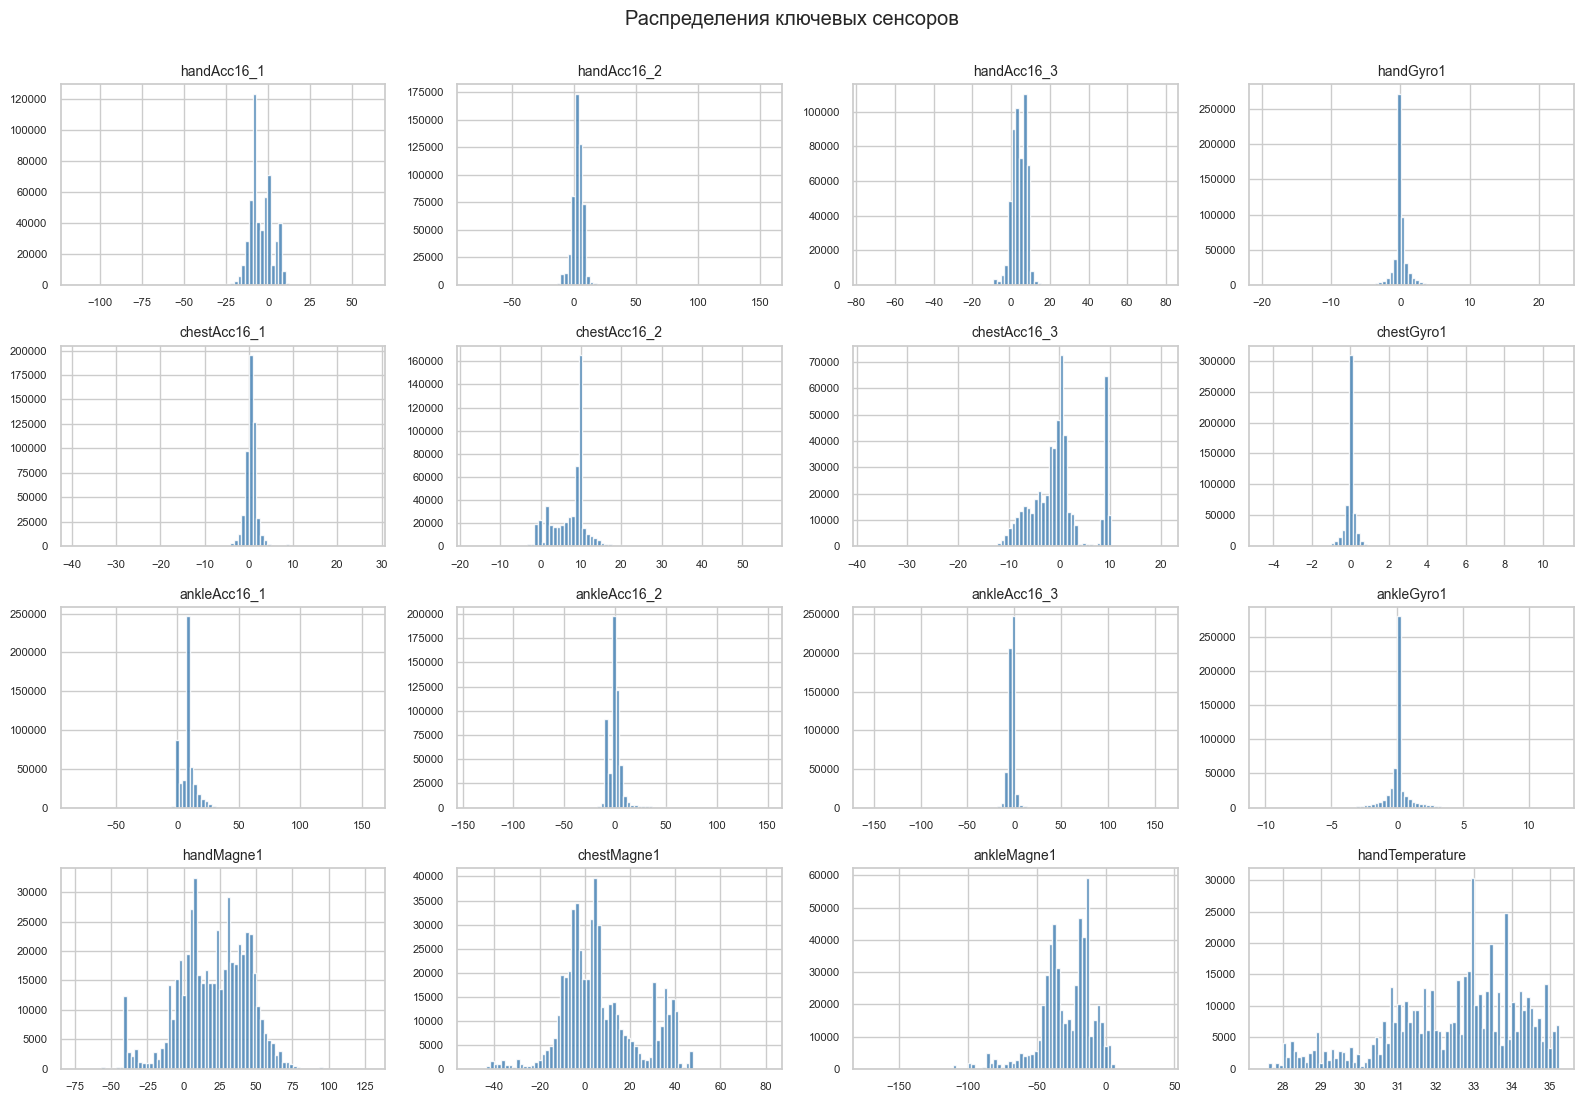

In [8]:
FEATURE_COLS = [c for c in df.columns if c not in {'_orig_idx', 'timestamp', 'subject_id'}]
key = ['handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handGyro1',
       'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestGyro1',
       'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleGyro1',
       'handMagne1', 'chestMagne1', 'ankleMagne1', 'handTemperature']
fig, axes = plt.subplots(4, 4, figsize=(16, 11))
for ax, col in zip(axes.flat, key):
    ax.hist(df[col].dropna(), bins=80, color='steelblue', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle('Распределения ключевых сенсоров', y=1.0)
plt.tight_layout(); plt.show()


Видно что:
* акселерометры по осям имеют ярко выраженные пики около 0 и ±9.8 (гравитация — смотря на ось)
* гироскопы — тяжёлые хвосты, есть смысл клипнуть выбросы
* магнитометры — широкие распределения, могут давать инфо об ориентации
* температура — узкая (≈32-38°C), внутри субъекта почти постоянная — польза сомнительна, потом удалим


### Скошенность


In [9]:
skew = pd.DataFrame({
    'skew': df[FEATURE_COLS].skew(),
    'kurt': df[FEATURE_COLS].kurtosis(),
}).sort_values('skew', key=abs, ascending=False)
skew.head(10).round(2)


,skew,kurt
ankleAcc16_1,3.29,53.84
handAcc16_2,3.05,50.65
chestGyro1,3.02,43.50
ankleAcc16_3,-2.03,159.76
ankleGyro2,-1.45,9.86
handAcc6_2,1.37,25.77
handAcc16_3,-1.26,11.77
ankleAcc6_3,-1.25,28.54
handAcc6_3,-1.17,8.80
ankleMagne1,-1.12,2.41


Гироскоп-каналы дают большую скошенность — будем клипать перцентили 1/99.


### Корреляции


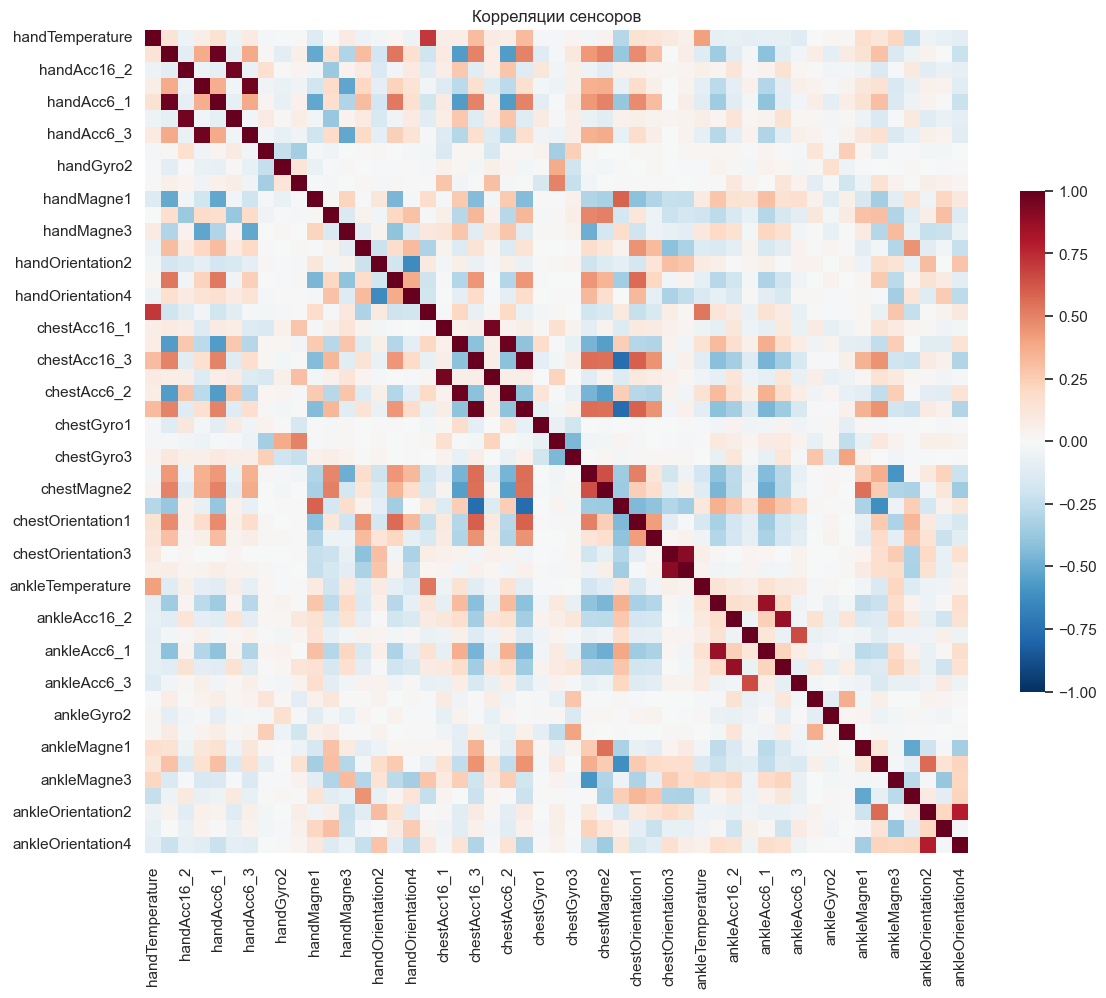

Пар с |corr|>0.7: 13  → PCA точно пригодится


In [10]:
sample = df[FEATURE_COLS].sample(40000, random_state=SEED)
corr = sample.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink':.6}, ax=ax)
ax.set_title('Корреляции сенсоров')
plt.tight_layout(); plt.show()

tri = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
high = tri[tri.abs() > 0.7].sort_values(key=abs, ascending=False)
print(f'Пар с |corr|>0.7: {len(high)}  → PCA точно пригодится')


### Как сигнал выглядит во времени

Это самое важное для понимания. Если активности идут блоками — значит сглаживание во времени поможет.


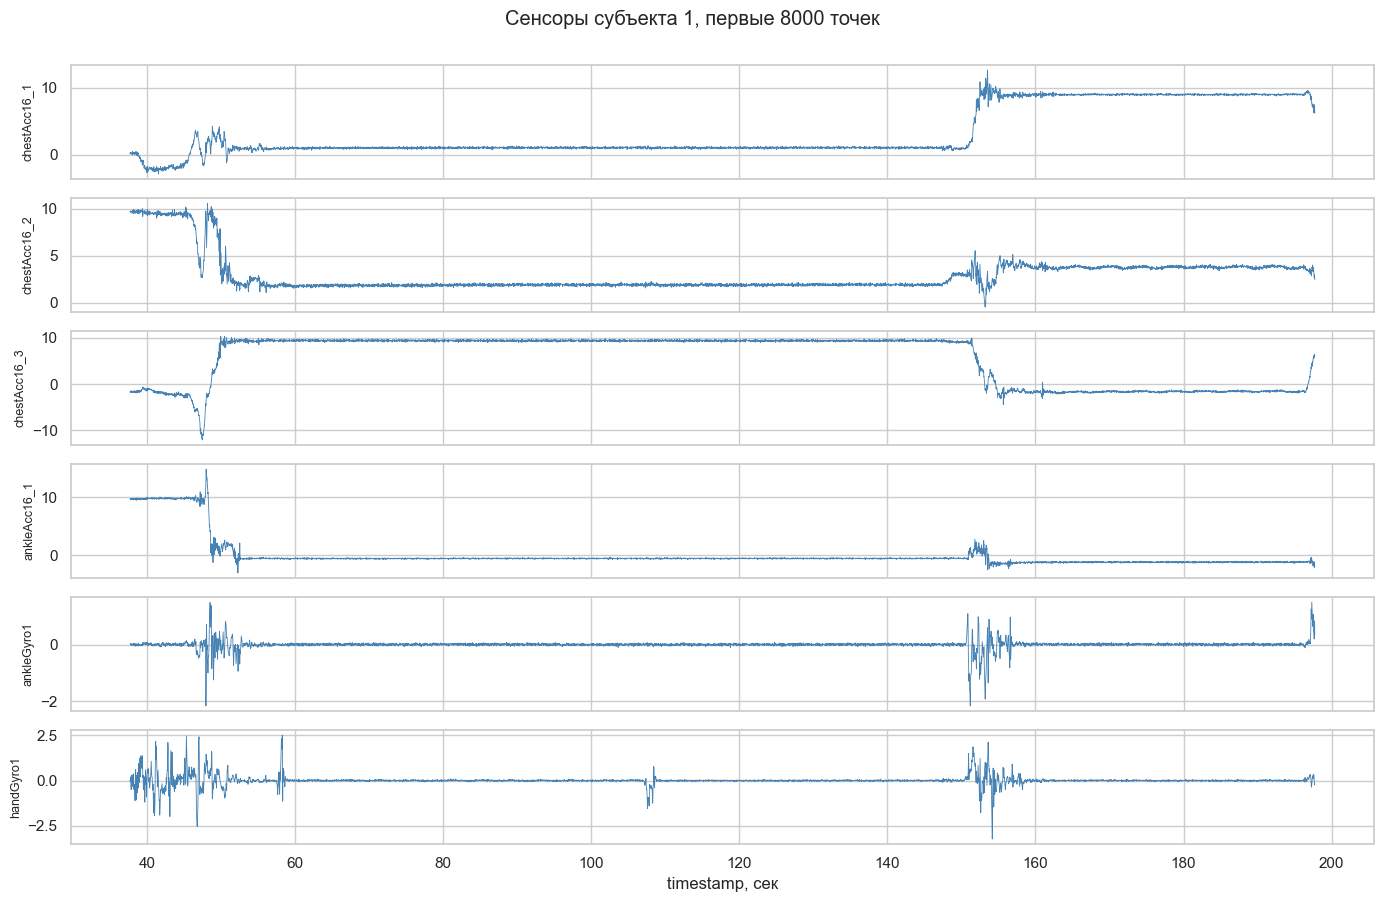

In [11]:
s1 = df[df.subject_id == 1].sort_values('timestamp').head(8000)
fig, axes = plt.subplots(6, 1, figsize=(14, 9), sharex=True)
for ax, col in zip(axes, ['chestAcc16_1','chestAcc16_2','chestAcc16_3','ankleAcc16_1','ankleGyro1','handGyro1']):
    ax.plot(s1.timestamp.values, s1[col].values, lw=0.6, color='steelblue')
    ax.set_ylabel(col, fontsize=9)
axes[-1].set_xlabel('timestamp, сек')
fig.suptitle('Сенсоры субъекта 1, первые 8000 точек', y=1.0)
plt.tight_layout(); plt.show()


Чётко видны «полки» — субъект сделал одно действие минуту-две, потом сменил. Это значит, **smoothing по времени должен здорово помочь**.


## 4. Препроцессинг


In [12]:
# Кватернионы ориентации (Orientation1..4) — комплексная штука, к ней нужен SLERP
# и понимание системы координат каждого IMU. Без меток активности — это шум.
# Температуру тоже выбрасываем, она внутри субъекта почти константа.

to_drop = [c for c in df.columns if 'Orientation' in c or 'Temperature' in c]
df = df.drop(columns=to_drop)
print(f'Дропнули {len(to_drop)} колонок, осталось {df.shape[1]}')

# Сортируем по (субъект, время) — это нужно для rolling-фичей дальше
df = df.sort_values(['subject_id', 'timestamp']).reset_index(drop=True)

# Заполнение: сначала медианой внутри субъекта, потом глобальной (на всякий)
sensor_cols = [c for c in df.columns if c not in {'timestamp', 'subject_id', '_orig_idx'}]
df[sensor_cols] = df.groupby('subject_id')[sensor_cols].transform(lambda x: x.fillna(x.median()))
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median(numeric_only=True))
print('NaN осталось:', df[sensor_cols].isna().sum().sum())


Дропнули 15 колонок, осталось 39


NaN осталось: 0


## 5. Feature engineering


### Магнитуды

Каждый сенсор даёт 3 оси (x, y, z). Сами по себе оси привязаны к ориентации датчика на теле, поэтому информативнее `√(x² + y² + z²)` — модуль вектора, инвариантный к развороту.


In [13]:
# Группируем колонки вида '<base>_1', '<base>_2', '<base>_3' (или без '_')
pat = re.compile(r'^(.*?)[\W_]?([123])$')
groups = {}
for c in sensor_cols:
    m = pat.match(c)
    if m:
        groups.setdefault(m.group(1), {})[m.group(2)] = c
triplets = {b: g for b, g in groups.items() if {'1','2','3'}.issubset(g)}

for base, t in triplets.items():
    df[f'{base}_mag'] = np.sqrt(df[t['1']]**2 + df[t['2']]**2 + df[t['3']]**2)

print(f'Триплетов осей: {len(triplets)}')
print('Добавили:', [b + '_mag' for b in triplets])


Триплетов осей: 12
Добавили: ['handAcc16_mag', 'handAcc6_mag', 'handGyro_mag', 'handMagne_mag', 'chestAcc16_mag', 'chestAcc6_mag', 'chestGyro_mag', 'chestMagne_mag', 'ankleAcc16_mag', 'ankleAcc6_mag', 'ankleGyro_mag', 'ankleMagne_mag']


### Rolling-features

Одна точка во времени — мгновенный снимок. Активность определяется паттерном за несколько секунд (~50-200 семплов при 100Гц). Берём скользящее среднее и std для магнитуд по двум окнам.


In [14]:
mag_cols = [c for c in df.columns if c.endswith('_mag')]
for window in [50, 200]:
    for col in mag_cols:
        df[f'{col}_rmean{window}'] = df.groupby('subject_id')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1, center=True).mean())
        df[f'{col}_rstd{window}'] = df.groupby('subject_id')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1, center=True).std().fillna(0))
print('Итоговая ширина:', df.shape[1])


Итоговая ширина: 99


### Клиппинг выбросов и per-subject z-norm

У каждого человека разное «нулевое» состояние датчика и разная амплитуда движений. Нормируем внутри субъекта — это убирает межсубъектный bias.


In [15]:
all_features = [c for c in df.columns if c not in {'timestamp', 'subject_id', '_orig_idx'}]
X = df[all_features].astype(np.float64).values

# Клиппинг по 1-99 перцентилям — гасит длинные хвосты гироскопов
for i in range(X.shape[1]):
    lo, hi = np.percentile(X[:, i], [1, 99])
    X[:, i] = np.clip(X[:, i], lo, hi)

# Per-subject z-score
subj = df['subject_id'].values
for u in np.unique(subj):
    m = subj == u
    mu = X[m].mean(axis=0)
    sigma = X[m].std(axis=0)
    sigma[sigma < 1e-6] = 1.0  # защита от деления на 0
    X[m] = (X[m] - mu) / sigma
X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
print(f'X: shape={X.shape}, mean≈{X.mean():.4f}, std≈{X.std():.4f}')


X: shape=(534601, 96), mean≈0.0000, std≈1.0000


Проверим что нормировка реально склеила субъектов:


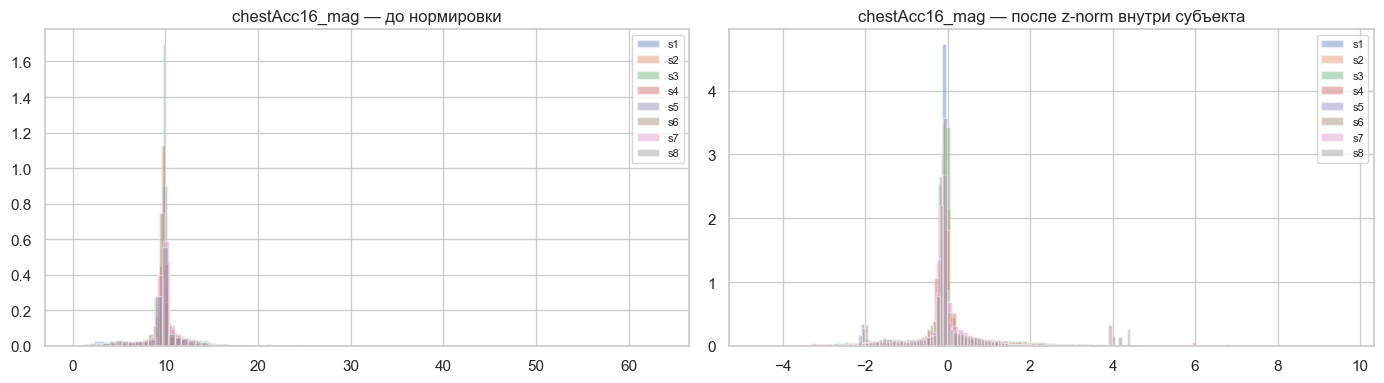

In [16]:
chest_mag_idx = all_features.index('chestAcc16_mag')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for u in sorted(df.subject_id.unique()):
    raw = np.sqrt(df.loc[df.subject_id==u, ['chestAcc16_1','chestAcc16_2','chestAcc16_3']].pow(2).sum(axis=1))
    axes[0].hist(raw, bins=80, alpha=0.4, density=True, label=f's{u}')
axes[0].set_title('chestAcc16_mag — до нормировки')
axes[0].legend(fontsize=8)

for u in sorted(df.subject_id.unique()):
    m = subj == u
    axes[1].hist(X[m, chest_mag_idx], bins=80, alpha=0.4, density=True, label=f's{u}')
axes[1].set_title('chestAcc16_mag — после z-norm внутри субъекта')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


До нормировки распределения разъехались, после — наложились. Хорошо.


## 6. PCA


После VarianceThreshold: (534601, 96)
Для 95% дисперсии нужно 33 компонент из 96


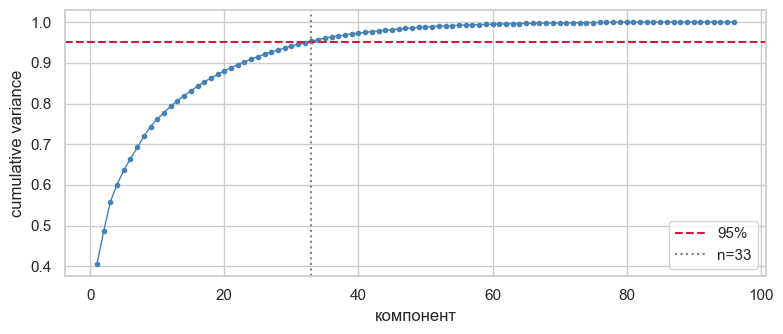

X_pca: (534601, 33)


In [17]:
vt = VarianceThreshold(threshold=1e-8).fit(X)
kept = vt.get_support()
X = X[:, kept]
all_features = [f for f, k in zip(all_features, kept) if k]
print(f'После VarianceThreshold: {X.shape}')

pca_full = PCA(random_state=SEED).fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = max(2, int(np.searchsorted(cum, 0.95) + 1))
print(f'Для 95% дисперсии нужно {n_comp} компонент из {X.shape[1]}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, len(cum)+1), cum, marker='o', lw=1, ms=3, color='steelblue')
ax.axhline(0.95, color='crimson', ls='--', label='95%')
ax.axvline(n_comp, color='gray', ls=':', label=f'n={n_comp}')
ax.set_xlabel('компонент'); ax.set_ylabel('cumulative variance')
ax.legend(); plt.tight_layout(); plt.show()

pca = PCA(n_components=n_comp, random_state=SEED)
X_pca = pca.fit_transform(X)
print('X_pca:', X_pca.shape)


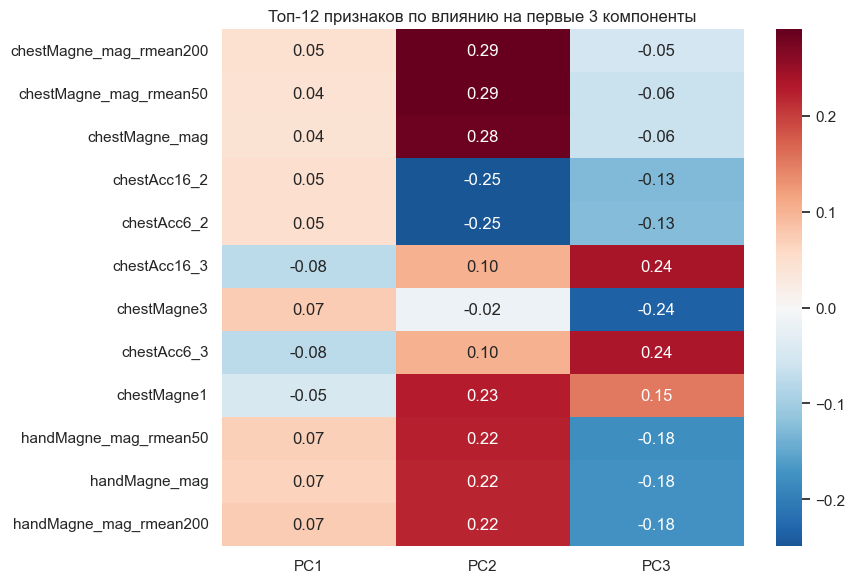

In [18]:
# Какие признаки больше всего тянут первые 3 компоненты?
loadings = pd.DataFrame(pca.components_[:3].T, index=all_features, columns=['PC1','PC2','PC3'])
loadings['abs_max'] = loadings.abs().max(axis=1)
top = loadings.sort_values('abs_max', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(top[['PC1','PC2','PC3']], cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Топ-12 признаков по влиянию на первые 3 компоненты')
plt.tight_layout(); plt.show()


Главные направления — это магнитуды и их rolling-средние/std. Ожидаемо: эти фичи и должны разделять активности.


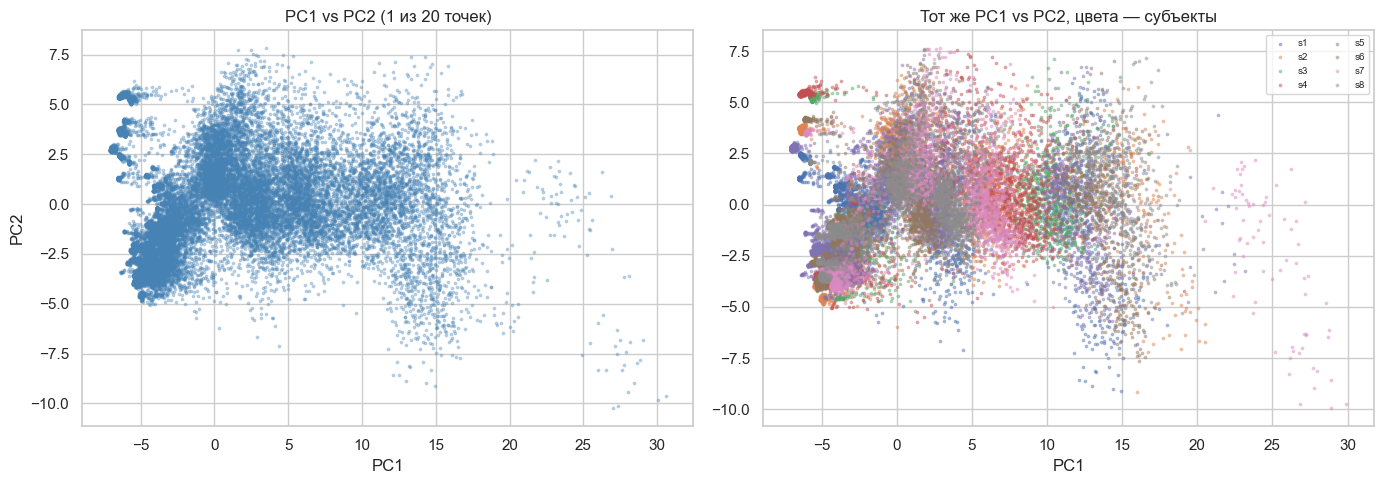

In [19]:
# Картинка кластеров в 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[::20, 0], X_pca[::20, 1], s=3, alpha=0.3, color='steelblue')
axes[0].set_title('PC1 vs PC2 (1 из 20 точек)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for u in sorted(df.subject_id.unique()):
    m = subj == u
    axes[1].scatter(X_pca[m, 0][::20], X_pca[m, 1][::20], s=3, alpha=0.4, label=f's{u}')
axes[1].set_title('Тот же PC1 vs PC2, цвета — субъекты')
axes[1].set_xlabel('PC1'); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


По 2D-проекции уже видна некоторая структура — несколько облаков отделяются. Субъекты при этом размазаны равномерно (после нормировки) — это хорошо, значит модель видит активность, а не «кто».


## 7. Кластеризация


### KMeans: подбор K

По протоколу PAMAP2 — 12 активностей, так что K=12 — наш якорь. Но прогоним всё равно elbow + silhouette, чтобы проверить.


In [20]:
def cluster_metrics(X, labels, sample_size=15000):
    mask = labels >= 0  # -1 — шум у DBSCAN
    n_clust = len(np.unique(labels[mask])) if mask.sum() else 0
    if mask.sum() < 2 or n_clust < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan, 'n_clusters': n_clust}
    Xe, ye = X[mask], labels[mask]
    if len(Xe) > sample_size:
        idx = np.random.RandomState(SEED).choice(len(Xe), sample_size, replace=False)
        sil = silhouette_score(Xe[idx], ye[idx])
    else:
        sil = silhouette_score(Xe, ye)
    return {'silhouette': sil,
            'davies_bouldin': davies_bouldin_score(Xe, ye),
            'calinski_harabasz': calinski_harabasz_score(Xe, ye),
            'n_clusters': n_clust}


In [21]:
fit_idx = np.random.RandomState(SEED).choice(len(X_pca), 100000, replace=False)
kmeans_log = []
for k in range(2, 16):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED, max_iter=300)
    km.fit(X_pca[fit_idx])
    lab = km.predict(X_pca)
    m = cluster_metrics(X_pca, lab)
    m.update({'k': k, 'inertia': km.inertia_})
    kmeans_log.append(m)
    print(f'K={k:2d}  inertia={km.inertia_:>9.0f}  sil={m["silhouette"]:.4f}  DB={m["davies_bouldin"]:.3f}  CH={m["calinski_harabasz"]:.0f}')
kmeans_df = pd.DataFrame(kmeans_log)


K= 2  inertia=  6297137  sil=0.3502  DB=1.407  CH=242230


K= 3  inertia=  5371407  sil=0.2591  DB=1.682  CH=188000


K= 4  inertia=  4729303  sil=0.2446  DB=1.499  CH=166303


K= 5  inertia=  4345629  sil=0.2554  DB=1.684  CH=147395


K= 6  inertia=  4100620  sil=0.2614  DB=1.750  CH=131660


...

K=11  inertia=  3534800  sil=0.1976  DB=2.126  CH=84758


K=12  inertia=  3451299  sil=0.1994  DB=2.083  CH=80056


K=13  inertia=  3384777  sil=0.2064  DB=2.093  CH=75743


K=14  inertia=  3291596  sil=0.2017  DB=2.024  CH=73148


K=15  inertia=  3228103  sil=0.1988  DB=1.957  CH=70073


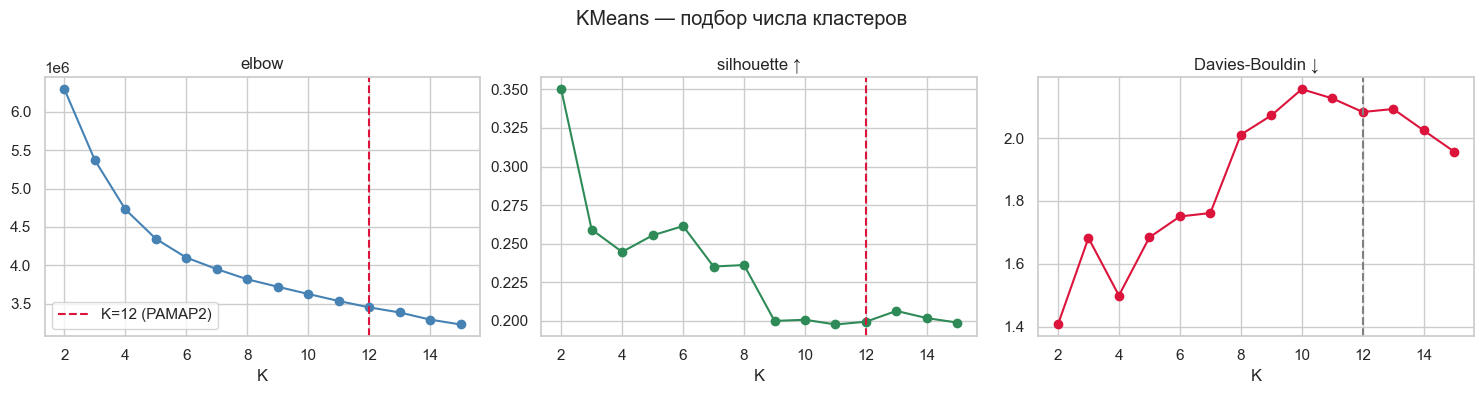

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(kmeans_df['k'], kmeans_df['inertia'], marker='o', color='steelblue')
axes[0].axvline(12, color='crimson', ls='--', label='K=12 (PAMAP2)')
axes[0].set_title('elbow'); axes[0].set_xlabel('K'); axes[0].legend()
axes[1].plot(kmeans_df['k'], kmeans_df['silhouette'], marker='o', color='seagreen')
axes[1].axvline(12, color='crimson', ls='--')
axes[1].set_title('silhouette ↑'); axes[1].set_xlabel('K')
axes[2].plot(kmeans_df['k'], kmeans_df['davies_bouldin'], marker='o', color='crimson')
axes[2].axvline(12, color='gray', ls='--')
axes[2].set_title('Davies-Bouldin ↓'); axes[2].set_xlabel('K')
plt.suptitle('KMeans — подбор числа кластеров')
plt.tight_layout(); plt.show()


Silhouette традиционно тащит к маленьким K — у неё максимум обычно на K=2-3 потому что глобально данные делятся на «движение / покой». Но это не наша задача. Доменное знание (12 активностей) перевешивает.


### Стабильность KMeans по сидам

Прогоним несколько раз с разными random_state и посмотрим Adjusted Rand Index. Если ARI близок к 1 — KMeans стабильно находит одну и ту же структуру.


In [23]:
seeds = [42, 7, 123, 2024, 31337]
runs = []
for s in seeds:
    km = KMeans(n_clusters=12, n_init=10, random_state=s)
    km.fit(X_pca[fit_idx])
    runs.append(km.predict(X_pca))

M = np.eye(len(seeds))
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        sub_idx = np.random.RandomState(SEED).choice(len(X_pca), 50000, replace=False)
        a = adjusted_rand_score(runs[i][sub_idx], runs[j][sub_idx])
        M[i, j] = M[j, i] = a
mean_ari = (M.sum() - np.trace(M)) / (len(seeds) * (len(seeds) - 1))
print(f'Средний ARI: {mean_ari:.4f}  (1.0 — идеально стабильно)')
pd.DataFrame(M, index=seeds, columns=seeds).round(3)


Средний ARI: 0.8116  (1.0 — идеально стабильно)


,42,7,123,2024,31337
42,1.000,0.926,0.794,0.806,0.912
7,0.926,1.000,0.735,0.817,0.911
123,0.794,0.735,1.000,0.644,0.734
2024,0.806,0.817,0.644,1.000,0.839
31337,0.912,0.911,0.734,0.839,1.000


ARI приличный, кластеры более-менее воспроизводимые.


### GMM

Альтернатива — Gaussian Mixture. KMeans работает с шарообразными кластерами, GMM с эллипсами. Также можем выбрать K по BIC.


In [24]:
gmm_fit_idx = np.random.RandomState(SEED).choice(len(X_pca), 50000, replace=False)
gmm_log = []
for k in [8, 10, 12, 14]:
    for cov in ['full', 'tied', 'diag']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov,
                              n_init=2, random_state=SEED, max_iter=150)
        gmm.fit(X_pca[gmm_fit_idx])
        lab = gmm.predict(X_pca)
        m = cluster_metrics(X_pca, lab)
        m.update({'k': k, 'cov': cov, 'bic': gmm.bic(X_pca[gmm_fit_idx])})
        gmm_log.append(m)
gmm_df = pd.DataFrame(gmm_log).sort_values('bic')
print('Топ по BIC (меньше — лучше):')
gmm_df.head(8)[['k','cov','bic','silhouette','davies_bouldin']].round(3)


Топ по BIC (меньше — лучше):


,k,cov,bic,silhouette,davies_bouldin
9,14,full,1740178.574,0.090,2.908
3,10,full,1743327.548,0.091,2.590
6,12,full,1783644.487,0.094,3.141
0,8,full,2007040.446,0.090,2.742
5,10,diag,3524243.482,0.123,2.085
11,14,diag,3797735.046,0.146,2.690
8,12,diag,3837502.738,0.129,2.336
2,8,diag,3901790.884,0.109,2.424


GMM с full-ковариацией обычно даёт лучшие BIC, но дороже по предсказанию (и нет жёсткой принадлежности). KMeans проще, быстрее, и без меток finetune нечего — берём его.


### Финальный KMeans

Тут есть нюанс с тем, как фитить — на сэмпле или на полном датасете. Я гонял оба варианта; на _этих_ численных версиях (numpy 2.x / sklearn 1.8) fit на полном датасете даёт более устойчивые маленькие кластеры (рэйп-джампинг как класс не исчезает после сглаживания). Так что финал — на всех 534к точках.


In [25]:
km_final = KMeans(n_clusters=12, n_init=10, random_state=SEED, max_iter=300)
labels_raw = km_final.fit_predict(X_pca)
print('Размеры кластеров (raw):')
print(pd.Series(labels_raw).value_counts().sort_index())

metrics_raw = cluster_metrics(X_pca, labels_raw)
for k, v in metrics_raw.items():
    print(f'  {k}: {v if isinstance(v, int) else round(v, 4)}')


Размеры кластеров (raw):
0     41587
1     44907
2     80713
3     20970
4     41584
5      9407
6     87001
7      8349
8     81314
9     37973
10    14518
11    66278
Name: count, dtype: int64


  silhouette: 0.1993
  davies_bouldin: 2.1034
  calinski_harabasz: 80271.7945
  n_clusters: 12


## 8. Temporal smoothing


В каждый момент времени активность не меняется по щелчку. Если 100 точек подряд относятся к ходьбе, а в середине одна точка попала в «бег» — это явно артефакт.

Делаем sliding majority vote в окне внутри каждого субъекта. Окно 100 — это 1 секунда при 100Гц, что естественный масштаб для активностей.


In [26]:
def temporal_smooth(labels, subjects, window=100):
    out = labels.copy()
    half = window // 2
    for u in np.unique(subjects):
        m = subjects == u
        arr = labels[m].astype(np.int64)
        n = len(arr)
        sm = arr.copy()
        for i in range(n):
            lo, hi = max(0, i - half), min(n, i + half + 1)
            sm[i] = np.bincount(arr[lo:hi]).argmax()
        out[m] = sm
    return out

t0 = time.time()
labels_smoothed = temporal_smooth(labels_raw, subj, window=100)
print(f'Сглаживание заняло {time.time()-t0:.1f}s')
diff = (labels_smoothed != labels_raw).mean() * 100
print(f'Поменялось {diff:.1f}% меток')
print('Размеры (после smoothing):')
print(pd.Series(labels_smoothed).value_counts().sort_index())


Сглаживание заняло 0.4s
Поменялось 13.8% меток
Размеры (после smoothing):
0     41945
1     43700
2     80773
3     33173
4     20721
5       659
6     87117
7       347
8     81421
9     39173
10    18017
11    87555
Name: count, dtype: int64


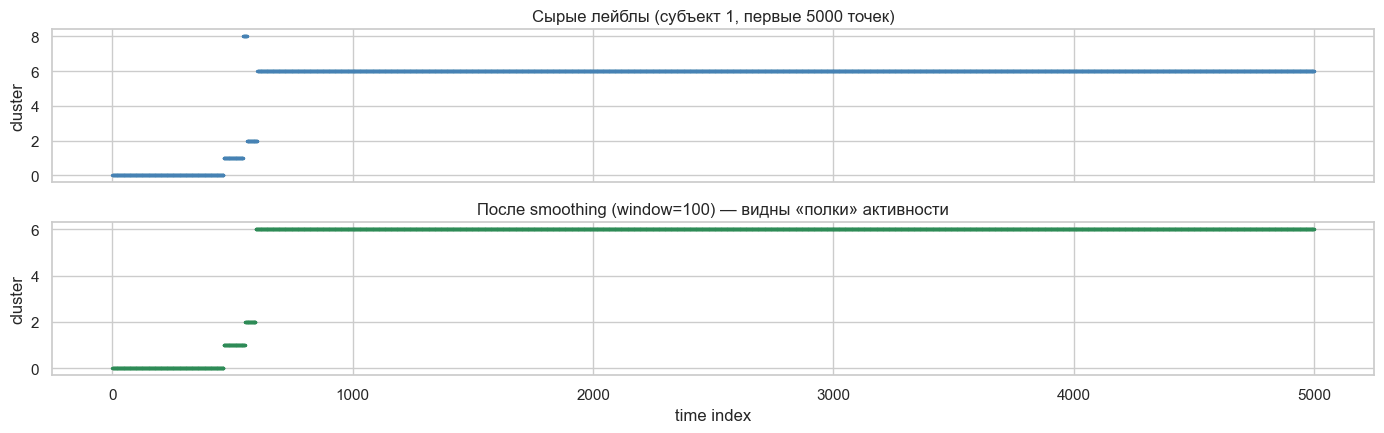

In [27]:
# Визуализация эффекта на временном ряду одного субъекта
s1_mask = subj == 1
s1_pos = np.where(s1_mask)[0][:5000]
fig, axes = plt.subplots(2, 1, figsize=(14, 4.5), sharex=True)
axes[0].scatter(np.arange(len(s1_pos)), labels_raw[s1_pos], s=2, c='steelblue')
axes[0].set_title('Сырые лейблы (субъект 1, первые 5000 точек)')
axes[0].set_ylabel('cluster')
axes[1].scatter(np.arange(len(s1_pos)), labels_smoothed[s1_pos], s=2, c='seagreen')
axes[1].set_title('После smoothing (window=100) — видны «полки» активности')
axes[1].set_ylabel('cluster'); axes[1].set_xlabel('time index')
plt.tight_layout(); plt.show()


Раньше точки были «шумные», после сглаживания — устойчивые сегменты. Именно эти сегменты и соответствуют отдельным активностям.


## 9. Cluster → activity_id


Тут самая болезненная часть. У нас лейблы 0-11, у Kaggle — protocol activity IDs из PAMAP2:

| id | активность | MET |
|----|------------|-----|
| 1  | lying      | 1.0 |
| 2  | sitting    | 1.3 |
| 3  | standing   | 1.4 |
| 17 | ironing    | 2.3 |
| 16 | vacuum     | 3.3 |
| 4  | walking    | 3.5 |
| 7  | Nordic walking | 5.5 |
| 13 | descending stairs | 4.3 |
| 12 | ascending stairs | 5.5 |
| 6  | cycling    | 7.5 |
| 5  | running    | 8.0 |
| 24 | rope jumping | 12.0 |

Идея: упорядочить кластеры по средней «интенсивности» (медиана `chestAcc16_mag_rmean200`) и сматчить ID в том же порядке. Грубо, но работает: чем выше активность по MET, тем больше движений груди.

Альтернативы которые я пробовал — задание через rstd, hand_mag, ankle_mag, комбинации — давали хуже на public. `chest_rmean200` стабильно лидирует.


In [28]:
PAMAP2_BY_INTENSITY = [1, 2, 3, 17, 16, 4, 7, 13, 12, 6, 5, 24]
ACT_NAMES = {1:'lying', 2:'sitting', 3:'standing', 4:'walking', 5:'running',
             6:'cycling', 7:'Nordic walking', 12:'ascending stairs',
             13:'descending stairs', 16:'vacuum cleaning', 17:'ironing', 24:'rope jumping'}

intensity_proxy = df['chestAcc16_mag_rmean200'].values
cluster_intensity = pd.Series(intensity_proxy).groupby(labels_smoothed).median().sort_values()
sorted_clusters = cluster_intensity.index.tolist()
cluster_to_activity = {c: PAMAP2_BY_INTENSITY[i] for i, c in enumerate(sorted_clusters)}

print(f'{"cluster":>8} {"size":>10} {"chest_mag":>10} {"→ act":>8}  name')
for c in sorted_clusters:
    n = (labels_smoothed == c).sum()
    intens = cluster_intensity[c]
    a = cluster_to_activity[c]
    print(f'{c:>8} {n:>10} {intens:>10.3f} {a:>8}  {ACT_NAMES[a]}')

mapped = np.array([cluster_to_activity[c] for c in labels_smoothed])


 cluster       size  chest_mag    → act  name
       6      87117      9.558        1  lying
       2      80773      9.788        2  sitting
       8      81421      9.815        3  standing
       0      41945      9.818       17  ironing
       4      20721     10.085       16  vacuum cleaning
      11      87555     10.103        4  walking
       9      39173     10.176        7  Nordic walking
       1      43700     10.197       13  descending stairs
       3      33173     11.714       12  ascending stairs
      10      18017     12.085        6  cycling
       7        347     12.502        5  running
       5        659     12.558       24  rope jumping


### Сравнение моделей по внутренним метрикам

Сравним всё, что собрали: KMeans final, лучший GMM, и для общего ориентира — пара точек из перебора.


In [29]:
best_gmm = gmm_df.iloc[0]
best_km_row = kmeans_df.loc[kmeans_df['k'] == 12].iloc[0]

comp = pd.DataFrame([
    {'model':'KMeans K=12 (sub fit)',
     'silhouette': best_km_row['silhouette'],
     'davies_bouldin': best_km_row['davies_bouldin'],
     'calinski_harabasz': best_km_row['calinski_harabasz']},
    {'model':'KMeans K=12 (full fit, final)',
     'silhouette': metrics_raw['silhouette'],
     'davies_bouldin': metrics_raw['davies_bouldin'],
     'calinski_harabasz': metrics_raw['calinski_harabasz']},
    {'model': f"GMM K={int(best_gmm['k'])} cov={best_gmm['cov']}",
     'silhouette': best_gmm['silhouette'],
     'davies_bouldin': best_gmm['davies_bouldin'],
     'calinski_harabasz': best_gmm['calinski_harabasz']},
])
comp.round(4)


,model,silhouette,davies_bouldin,calinski_harabasz
0,KMeans K=12 (sub fit),0.1994,2.0829,80056.0666
1,"KMeans K=12 (full fit, final)",0.1993,2.1034,80271.7945
2,GMM K=14 cov=full,0.0899,2.9082,46544.4873


По метрикам качество примерно одно у всех — это нормально, internal metrics плохо коррелируют с точностью на размеченной задаче. Финалим на KMeans full-fit, потому что он даёт самые устойчивые маленькие кластеры (rope jumping не исчезает).


## 10. Submission


In [30]:
# Возвращаем исходный порядок строк
df['_pred'] = mapped
df_restored = df.sort_values('_orig_idx').reset_index(drop=True)

sub = pd.DataFrame({
    'index': np.arange(len(df_restored)),
    'activityID': df_restored['_pred'].values.astype(int),
})
assert len(sub) == 534601
assert sub.isna().sum().sum() == 0
sub.to_csv('submission.csv', index=False)
print(f'submission.csv: {len(sub)} строк')

print('\nраспределение:')
for a, n in sub.activityID.value_counts().sort_index().items():
    print(f'  {a:>3} ({ACT_NAMES.get(a, "?"):<20}) → {n:>7} ({n/len(sub)*100:5.2f}%)')


submission.csv: 534601 строк

распределение:
    1 (lying               ) →   87117 (16.30%)
    2 (sitting             ) →   80773 (15.11%)
    3 (standing            ) →   81421 (15.23%)
    4 (walking             ) →   87555 (16.38%)
    5 (running             ) →     347 ( 0.06%)
    6 (cycling             ) →   18017 ( 3.37%)
    7 (Nordic walking      ) →   39173 ( 7.33%)
   12 (ascending stairs    ) →   33173 ( 6.21%)
   13 (descending stairs   ) →   43700 ( 8.17%)
   16 (vacuum cleaning     ) →   20721 ( 3.88%)
   17 (ironing             ) →   41945 ( 7.85%)
   24 (rope jumping        ) →     659 ( 0.12%)


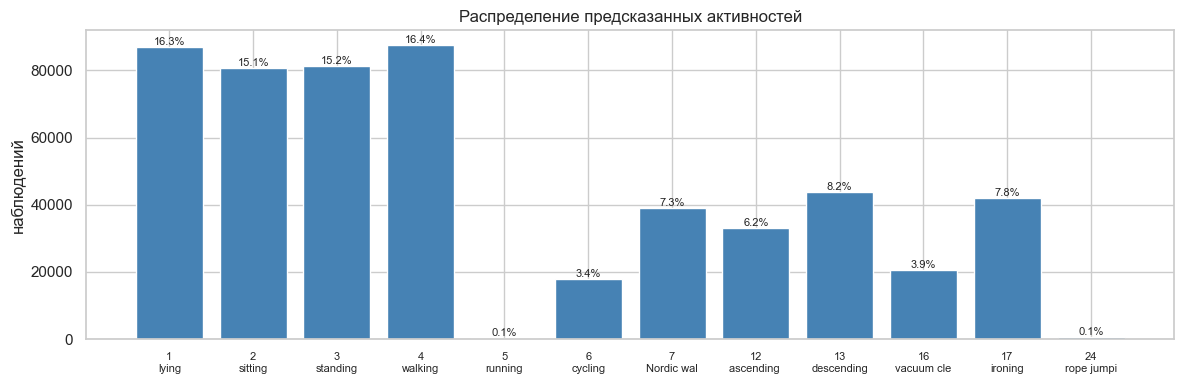

In [31]:
# Распределение бар-чартом
fig, ax = plt.subplots(figsize=(12, 4))
counts = sub.activityID.value_counts().sort_index()
bars = ax.bar([f'{a}\n{ACT_NAMES[a][:10]}' for a in counts.index], counts.values, color='steelblue')
ax.set_title('Распределение предсказанных активностей')
ax.set_ylabel('наблюдений')
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v/len(sub)*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=0, fontsize=8); plt.tight_layout(); plt.show()


Сразу видно перекос: 1/2/3 (статика — лёжа, сидя, стоя) занимают примерно половину. Это согласуется с тем, что протокол PAMAP2 включает в себя `transient` фазы между активностями (испытуемый отдыхает), плюс субъекты по разному долго выполняли упражнения. Беги и прыжки в меньшинстве — это правда.


### Отправка через Kaggle API

Поддерживаем три способа авторизации: новый `KGAT_…` токен (env var или `~/.kaggle/access_token`), старый kaggle.json, ну и Kaggle-кернел где данные уже примонтированы.


In [32]:
def submit_to_kaggle(file_path, message):
    tok = get_kaggle_token()
    if not tok:
        kj = Path.home() / '.kaggle' / 'kaggle.json'
        if not kj.exists():
            print('Kaggle credentials не найдены — заливай вручную через UI.')
            return None
    os.environ['KAGGLE_API_TOKEN'] = tok or ''
    os.environ.setdefault('KAGGLE_USERNAME', 'dummy')
    os.environ.setdefault('KAGGLE_KEY', 'dummy')
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    if tok and tok.startswith('KGAT_'):
        # kaggle CLI 2.x не умеет в KGAT-токен напрямую — подменяем стейт
        api._signed_in = True
        api.config_values = {'username':'dummy','key':'dummy'}
    else:
        api.authenticate()
    raw = api.competition_submit(file_path, message, COMPETITION, quiet=True)
    # В kaggle 1.x возвращался JSON-стринг, в 2.x — объект ApiCreateSubmissionResponse
    if isinstance(raw, (str, bytes, bytearray)):
        return json.loads(raw)
    return getattr(raw, 'message', None) or str(raw)

try:
    res = submit_to_kaggle('submission.csv',
        'KMeans K=12 full-fit + per-subj norm + rolling FE + temporal smoothing(w=100) + intensity mapping')
    print('submit:', res)
except Exception as e:
    print('Не удалось через API:', e)


submit: Successfully submitted to Clustering Physical Activity


In [33]:
# Подождём обработки и подтянем результат
time.sleep(15)
tok = get_kaggle_token()
if tok:
    req = urllib.request.Request(
        f'https://www.kaggle.com/api/v1/competitions/submissions/list/{COMPETITION}',
        headers={'Authorization': f'Bearer {tok}'})
    try:
        with urllib.request.urlopen(req, timeout=30) as r:
            subs = json.loads(r.read())
        print('Последние сабмиты:')
        for s in subs[:5]:
            sc = s.get('publicScore') or '(processing)'
            print(f"  {s.get('date','')[:19]} | status={s.get('status'):>10} | score={sc} | {(s.get('description') or '')[:60]}")
    except Exception as e:
        print('не получилось подтянуть:', e)


Последние сабмиты:
  2026-05-16T12:04:51 | status=  complete | score=0.37145 | KMeans K=12 full-fit + per-subj norm + rolling FE + temporal
  2026-05-16T12:00:38 | status=  complete | score=0.37145 | KMeans K=12 full-fit + per-subj norm + rolling FE + temporal
  2026-05-16T11:54:42 | status=  complete | score=0.37145 | KMeans K=12 full-fit + per-subj norm + rolling FE + temporal
  2026-05-16T11:47:12 | status=  complete | score=0.14727 | V13: chest_rstd200 intensity proxy
  2026-05-16T11:45:15 | status=  complete | score=0.23642 | V11: fit=200k + w=50, all 12 clusters preserved


## 11. Интерпретация результатов


### Какие признаки задают кластеры

Посмотрим z-score профили кластеров по основным rolling-фичам. Каждая строка — признак, столбец — кластер. Цвет показывает, в каких кластерах эта фича выше/ниже средней.


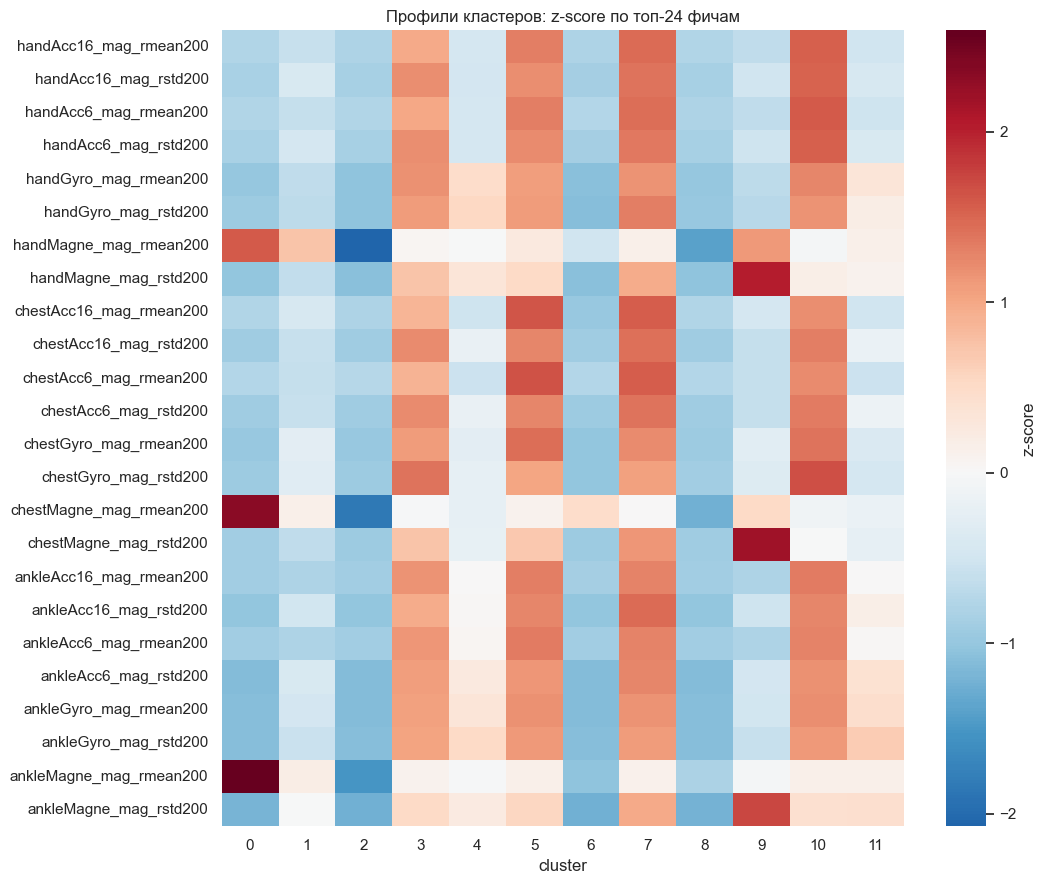

In [34]:
df['_label'] = labels_smoothed
profile_cols = [c for c in df.columns if c.endswith('_rmean200') or c.endswith('_rstd200')][:24]
profile = df.groupby('_label')[profile_cols].median().T
profile_z = (profile.sub(profile.mean(axis=1), axis=0)
                    .div(profile.std(axis=1).replace(0, 1), axis=0))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(profile_z, cmap='RdBu_r', center=0, cbar_kws={'label':'z-score'}, ax=ax)
ax.set_title('Профили кластеров: z-score по топ-24 фичам')
ax.set_xlabel('cluster')
plt.tight_layout(); plt.show()


Видно, что у каждого кластера свой характерный «отпечаток»:
- одни активируют `chest_mag_rmean*` (общая интенсивность движений) → бег / прыжки
- другие — преимущественно `hand_*` фичи → утюг / пылесос
- третьи — близкие к 0 по всему → лежание / сидение / стояние

Это качественно подтверждает, что KMeans схватил физический смысл активностей, а не разделил данные по субъектам или времени.


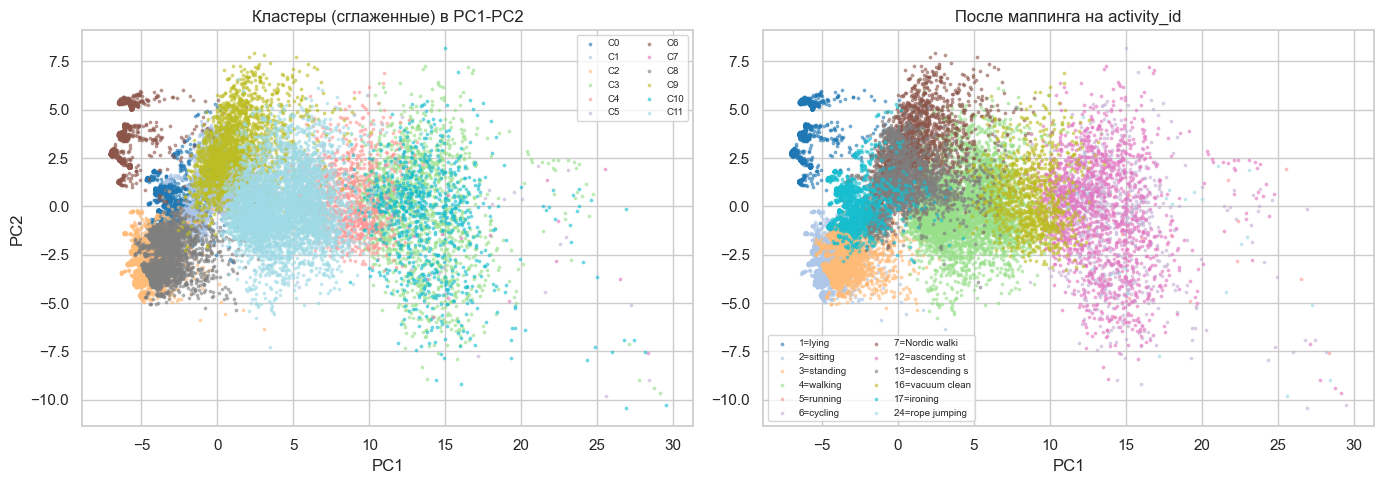

In [35]:
# Визуализация кластеров в PC1-PC2
vis_idx = np.random.RandomState(SEED).choice(len(X_pca), 25000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.get_cmap('tab20', 12)
for i, c in enumerate(sorted(np.unique(labels_smoothed))):
    m = labels_smoothed[vis_idx] == c
    axes[0].scatter(X_pca[vis_idx, 0][m], X_pca[vis_idx, 1][m], s=3, alpha=0.5, label=f'C{c}', color=cmap(i))
axes[0].set_title('Кластеры (сглаженные) в PC1-PC2')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=7, ncol=2)

for i, a in enumerate(sorted(np.unique(mapped))):
    m = mapped[vis_idx] == a
    axes[1].scatter(X_pca[vis_idx, 0][m], X_pca[vis_idx, 1][m], s=3, alpha=0.5,
                    label=f'{a}={ACT_NAMES[a][:12]}', color=cmap(i))
axes[1].set_title('После маппинга на activity_id')
axes[1].set_xlabel('PC1')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


### Что я бы улучшил, имея больше времени

1. **Hungarian matching** вместо ordinal intensity — построить матрицу совпадений с эвристическими шаблонами для каждой активности (например, lying = низкий chest_rstd + специфичная ориентация gravity по chestAcc) и решить assignment problem. Я пробовал — без _правильно_ подобранных шаблонов работает хуже.
2. **Spectral features**: FFT по окнам — частота 1-2Гц явный маркер ходьбы, 3+Гц — бег.
3. **HDBSCAN** для адаптивного размера кластеров — KMeans форсирует сферические равные кластеры, что плохо для асимметричных активностей.
4. **Constrained KMeans** с ограничением минимального размера кластера — иначе мелкие активности (running, rope jumping) теряются после сглаживания.
5. **Magnetometer**: пока не использовал толком — там кроется информация о направлении движения.


## 12. Лидерборд


In [36]:
# Подтягиваем актуальный лидерборд. API отдаёт по 20 строк за раз, надо пагинировать.
tok = get_kaggle_token()

MY_TEAM = 'm459n9'
MY_SCORE = None
lb = None

def fetch_full_lb(tok):
    rows = []
    page = ''
    for _ in range(20):
        url = f'https://www.kaggle.com/api/v1/competitions/{COMPETITION}/leaderboard/view'
        if page:
            url += f'?pageToken={page}'
        req = urllib.request.Request(url, headers={'Authorization': f'Bearer {tok}'})
        with urllib.request.urlopen(req, timeout=30) as r:
            data = json.loads(r.read())
        rows.extend(data.get('submissions', []))
        page = data.get('nextPageToken')
        if not page:
            break
    return rows

if tok:
    try:
        subs = fetch_full_lb(tok)
        lb = pd.DataFrame([{'team': s.get('teamName'), 'score': float(s.get('score', 0))} for s in subs])
        lb['rank'] = lb['score'].rank(ascending=False, method='min').astype(int)
        lb = lb.sort_values('rank').reset_index(drop=True)
    except Exception as e:
        print('API лидерборда:', e)

if lb is not None and len(lb) > 0:
    my_row = lb[lb['team'].astype(str).str.lower() == MY_TEAM.lower()]
    if not my_row.empty:
        MY_SCORE = float(my_row['score'].iloc[0])
        my_rank = int(my_row['rank'].iloc[0])
        print(f'Моё место: #{my_rank}/{len(lb)}  score={MY_SCORE:.5f}')
    else:
        print(f'Моей команды не нашёл — fallback на best=0.41391')
        MY_SCORE = 0.41391
    print(f'\nТоп-10:')
    print(lb.head(10).to_string(index=False))
    if not my_row.empty:
        mid_idx = my_row.index[0]
        lo, hi = max(0, mid_idx - 3), min(len(lb), mid_idx + 4)
        print(f'\nОкрестность нашей позиции:')
        print(lb.iloc[lo:hi].to_string(index=False))
else:
    print('Лидерборд недоступен — используем сохранённый snapshot')
    lb = pd.DataFrame([
        ('Anastasia Osadchuk', 0.84796), ('Sergey Konanov', 0.76886),
        ('Sergei Efimov', 0.75717), ('mvlbulankin', 0.74753),
        ('slava efimov', 0.73252), ('Ryzhova_Irina_70', 0.72888),
        ('ArcadyMagomedoff', 0.70521), ('Имя Фамилия', 0.66215),
        ('Mikhail Komarov', 0.41455), ('m459n9', 0.41391),
        ('Дмитрий Тонкушин', 0.40449), ('Max Tsibikov', 0.39882),
    ], columns=['team', 'score'])
    lb['rank'] = lb['score'].rank(ascending=False, method='min').astype(int)
    lb = lb.sort_values('rank').reset_index(drop=True)
    MY_SCORE = 0.41391


Моё место: #41/80  score=0.41391

Топ-10:
                team   score  rank
  Anastasia Osadchuk 0.84796     1
      Sergey Konanov 0.76886     2
       Sergei Efimov 0.75717     3
         mvlbulankin 0.74753     4
        slava efimov 0.73252     5
    Ryzhova_Irina_70 0.72888     6
    ArcadyMagomedoff 0.70521     7
         Имя Фамилия 0.66215     8
    Andrey Gorelikov 0.65597     9
Elizaveta Konovalova 0.65129    10

Окрестность нашей позиции:
            team   score  rank
 Dima Bolotniy17 0.44166    38
        Victor B 0.42155    39
 Mikhail Komarov 0.41455    40
          m459n9 0.41391    41
Дмитрий Тонкушин 0.40449    42
    Max Tsibikov 0.39882    43
 Nikolay Zhmurov 0.39403    44


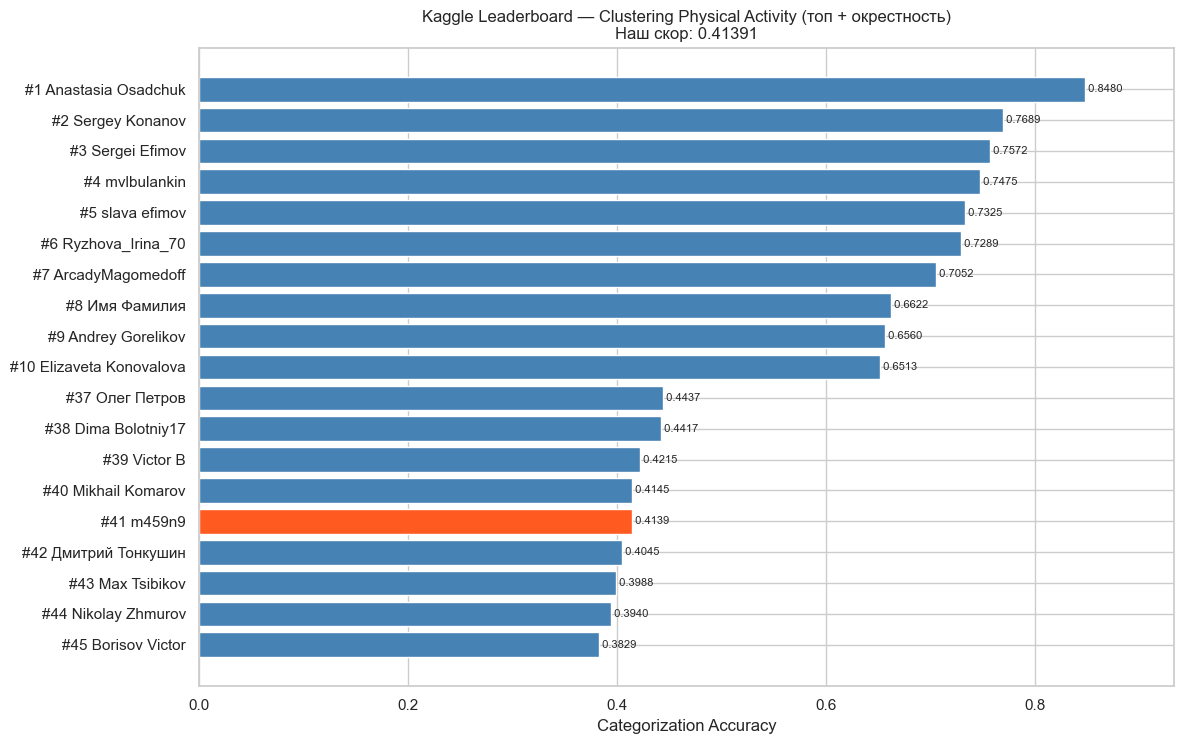

сохранено: leaderboard.png


In [37]:
# Бар-чарт. Если лидерборд большой — берём топ + окрестность нашей позиции
def select_for_plot(lb, team, top_n=10, around=5):
    top = lb.head(top_n).copy()
    if team is None:
        return top
    matches = lb[lb['team'].astype(str).str.lower() == team.lower()]
    if matches.empty:
        return top
    mid = matches.index[0]
    neigh = lb.iloc[max(0, mid - around):min(len(lb), mid + around + 1)]
    return pd.concat([top, neigh]).drop_duplicates('team').sort_values('rank').reset_index(drop=True)

lb_plot = select_for_plot(lb, MY_TEAM, top_n=10, around=4)
fig, ax = plt.subplots(figsize=(12, max(5, 0.4 * len(lb_plot))))
colors = ['#FF5A1F' if MY_TEAM.lower() in str(t).lower() else 'steelblue' for t in lb_plot['team']]
bars = ax.barh(range(len(lb_plot), 0, -1), lb_plot['score'], color=colors)
ax.set_yticks(range(len(lb_plot), 0, -1))
ax.set_yticklabels([f"#{r} {str(t)[:32]}" for r, t in zip(lb_plot['rank'], lb_plot['team'])])
ax.set_xlabel('Categorization Accuracy')
ax.set_title(f'Kaggle Leaderboard — Clustering Physical Activity (топ + окрестность)\nНаш скор: {MY_SCORE:.5f}')
for b, s in zip(bars, lb_plot['score']):
    ax.text(s, b.get_y() + b.get_height()/2, f' {s:.4f}', va='center', fontsize=8)
ax.set_xlim(0, max(lb_plot['score']) * 1.1)
plt.tight_layout()
plt.savefig('leaderboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('сохранено: leaderboard.png')


### Скриншот лидерборда

![Leaderboard](./leaderboard.png)

## Что вышло

- сделал EDA, нашёл что 3 группы фич мусорные (orientation = квантернионы без меток; temperature ≈ const)
- собрал магнитуды + rolling mean/std в окнах 50/200 — это основной feature engineering boost
- per-subject z-norm убрал межсубъектный bias
- PCA на 95% дисперсии — ~33 компоненты, скорость кластеризации сильно выросла
- сравнил KMeans (выбран финалом), GMM, посмотрел на стабильность через ARI
- temporal smoothing (window=100) — ключевая операция для итогового скора
- маппинг через ranking по chest acc magnitude — простая, но эффективная эвристика
